<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Handling_Missing_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handling Mising Data
1. Remove the row (Complete Case Analysis/CCA)
2. To impute (fill)
    - Univariate (Simple Imputer Class)
        - Numerical
            - Mean/Median
            - Random
            - End of distribution value
        - Categorical
            - Mode
            - Missing

    - Multivariate
        - KNN Imputer
        - Iterative imputer (MICE)


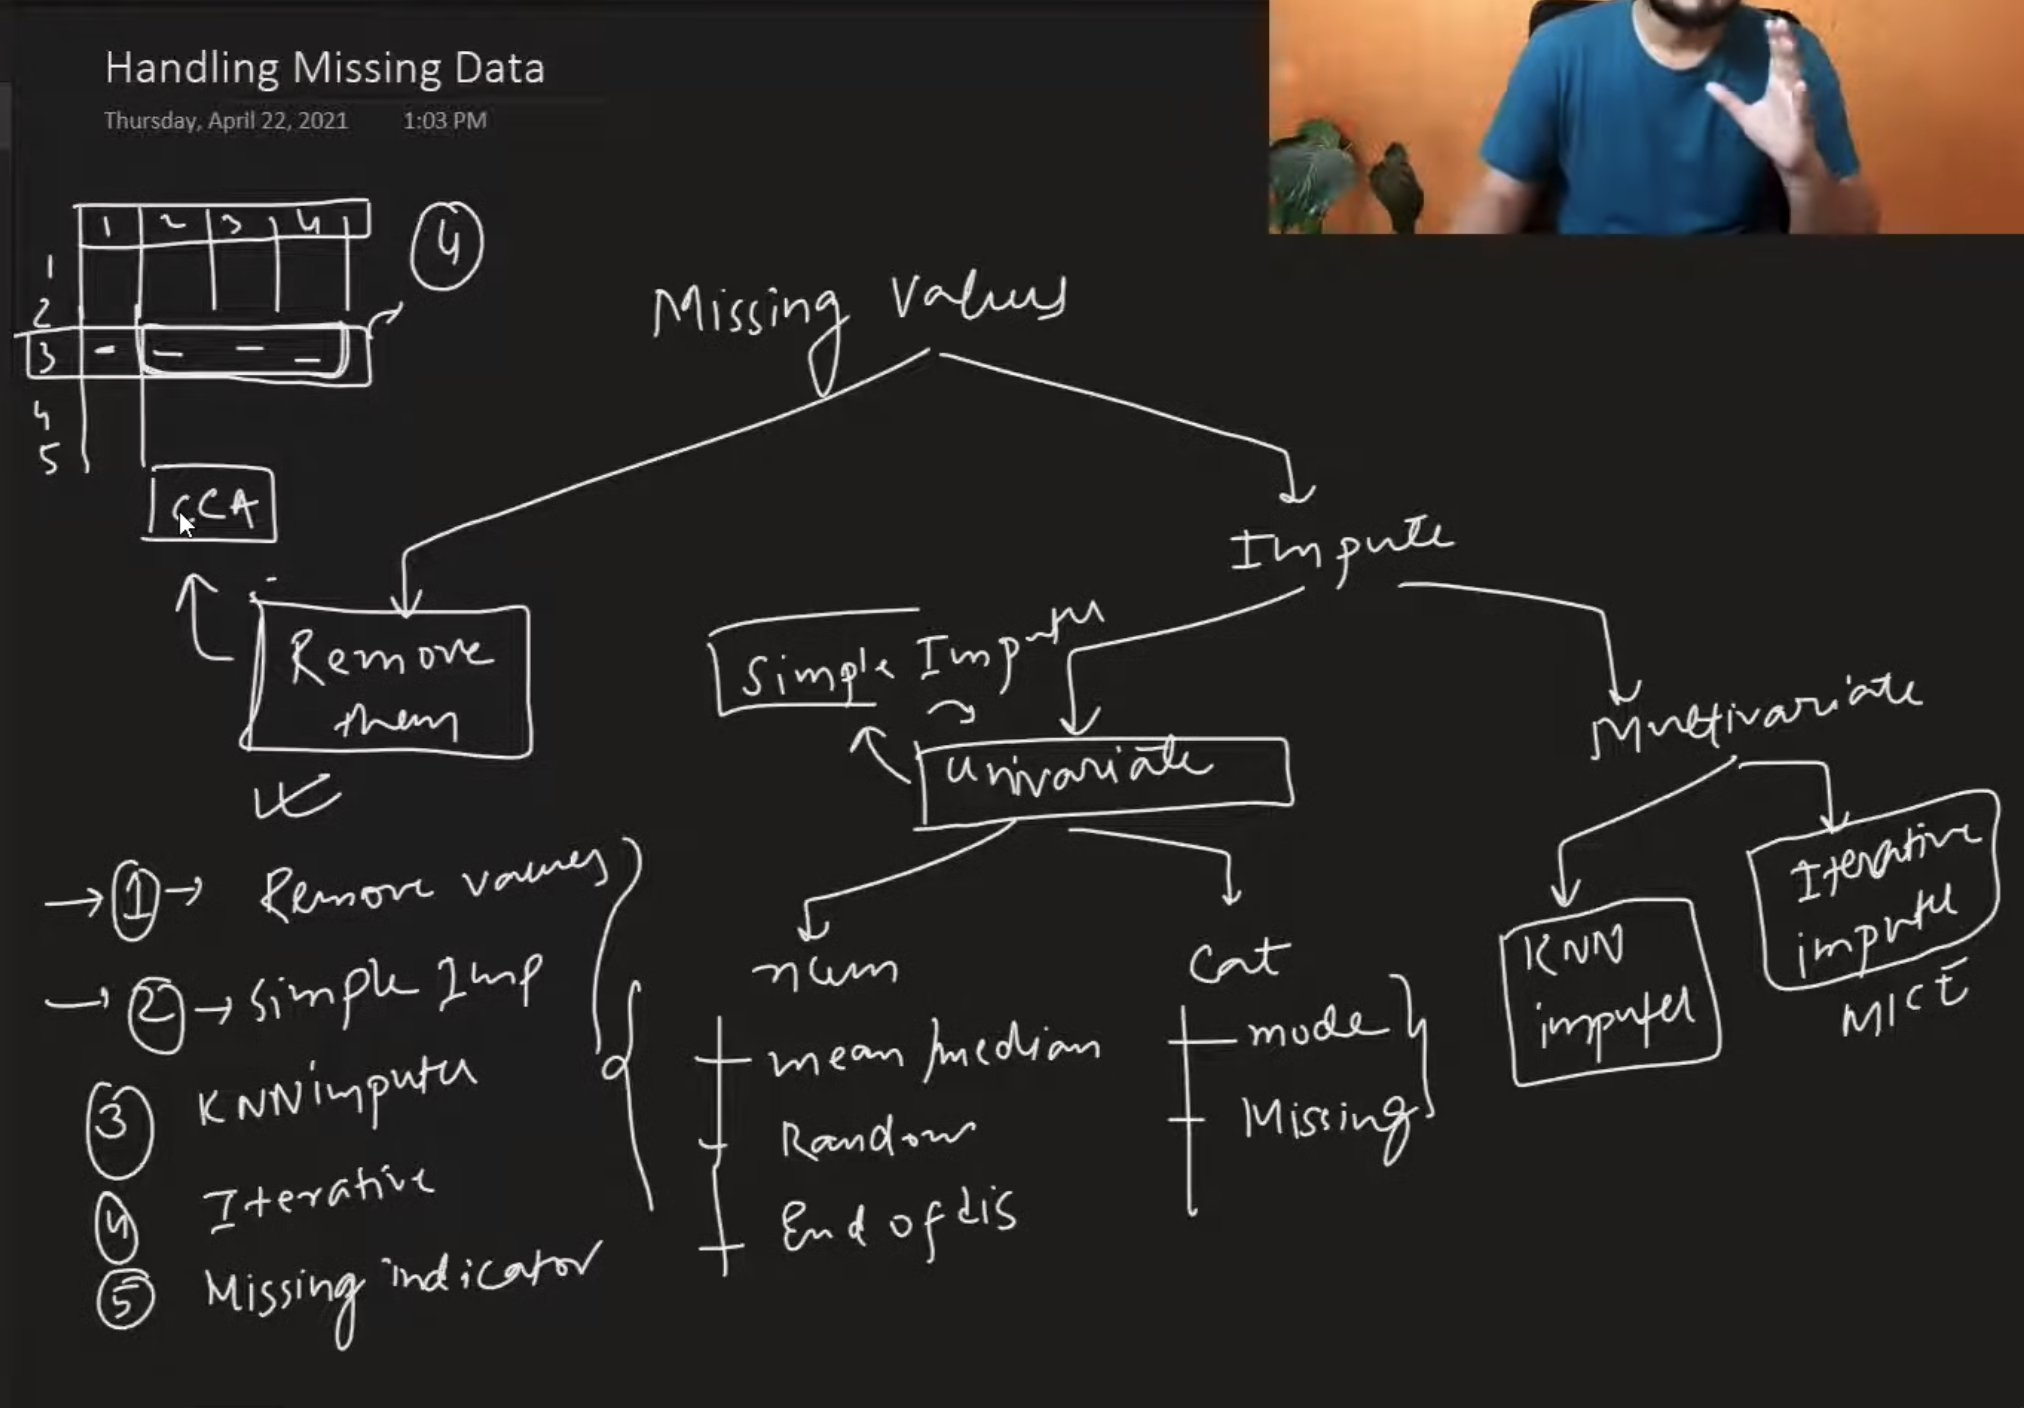

# Complete Case Analysis
Complete-case analysis (CCA), also called "list-wise deletion" of cases, consists in discarding observations where values in any of the variables are missing.

Complete Case Analysis means literally analyzing only those observations for which there is information in all of the variables in the dataset.

## Assumption
1. Missing completely at Random

## Advantage
1. Easy to implement as no data manipulation required
2. Preserves variable distribution (if data is MCAR, then the distribution of the variables of the reduced dataset should match the distribution in the original dataset)
## Disadvantage
1. It can exclude a large fraction of the original dataset (if missing data is abundant)
2. Excluded observations could be informative for the analysis (if data is not missing at random)
3. When using our models in production, the model will not know how to handle missing data

# When to use CCA?
1. MCAR
2. 5% < missing data

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day35-complete-case-analysis/data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [6]:
df.shape

(19158, 13)

In [11]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [13]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
14188,0.926,Full time course,High School,4.0,92.0
1893,0.926,Full time course,Graduate,3.0,54.0
2687,0.878,Full time course,Graduate,9.0,21.0
16466,0.939,no_enrollment,Graduate,20.0,35.0
14153,0.915,no_enrollment,Graduate,14.0,NaN


In [14]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [15]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

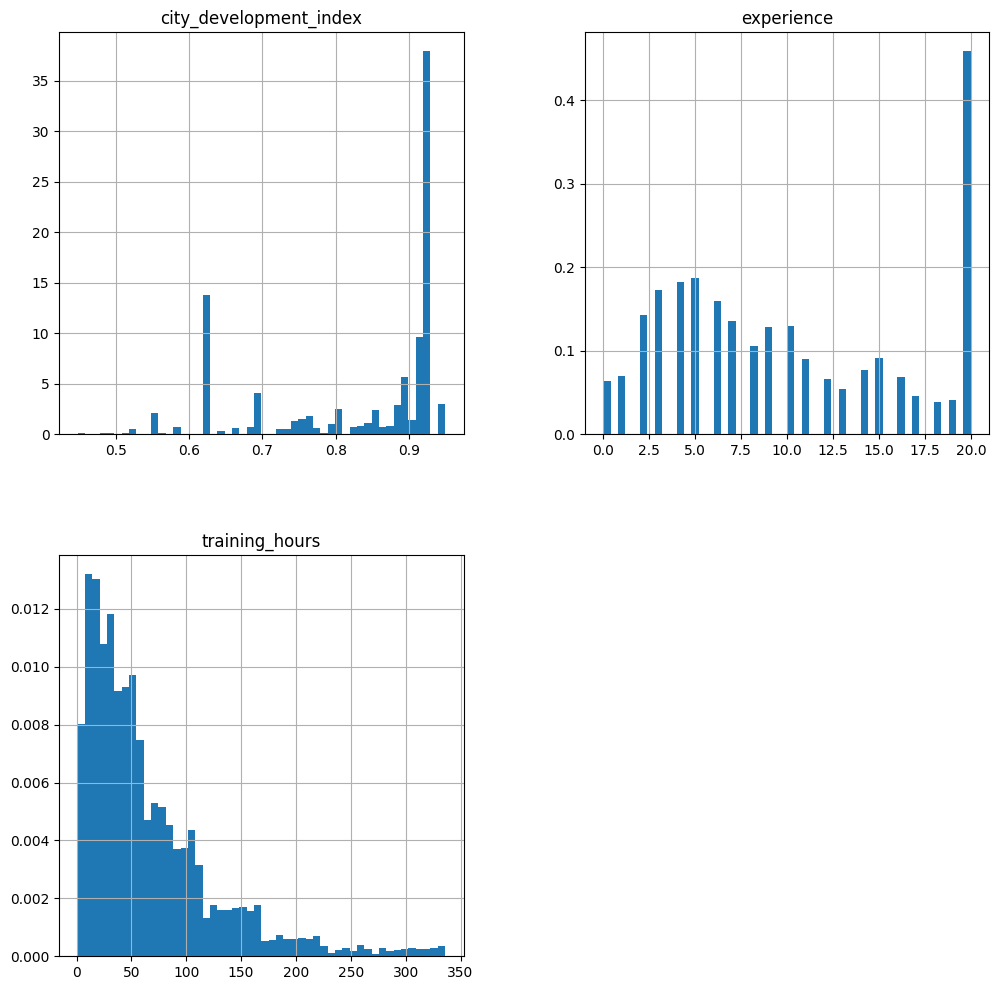

In [17]:
import matplotlib.pyplot as plt

new_df.hist(bins=50, density=True, figsize=(12,12))
plt.show()

<Axes: >

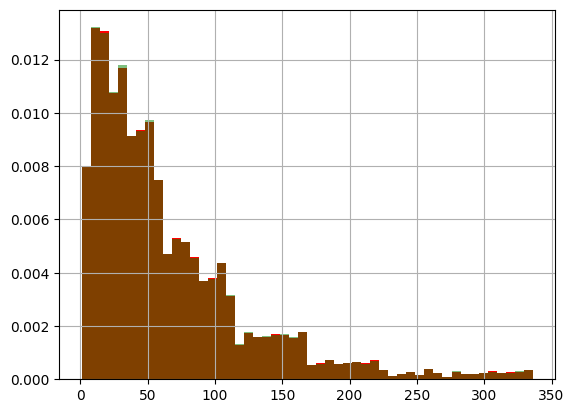

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)
# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red', alpha=1)
# data after cca
new_df['training_hours'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.5)

<Axes: ylabel='Density'>

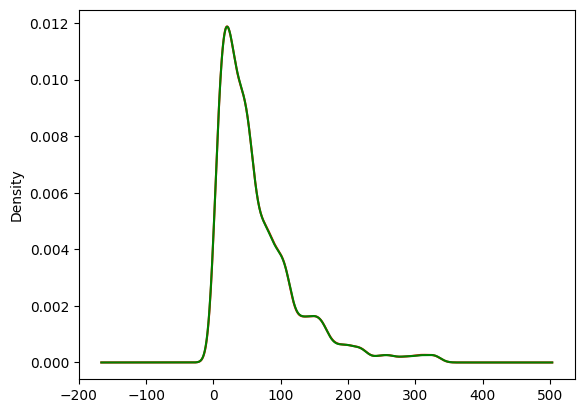

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['training_hours'].plot.density(color='red')
new_df['training_hours'].plot.density(color='green')

<Axes: ylabel='Density'>

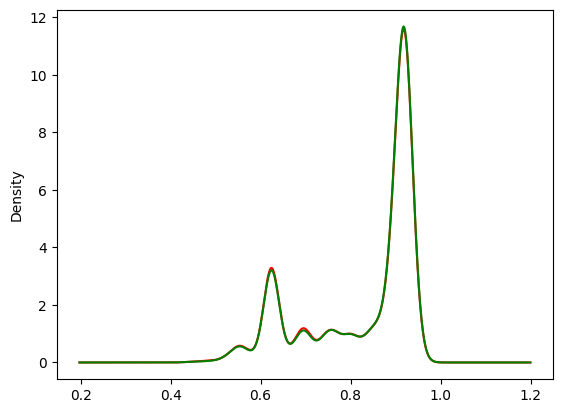

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['city_development_index'].plot.density(color='red')
new_df['city_development_index'].plot.density(color='green')

<Axes: ylabel='Density'>

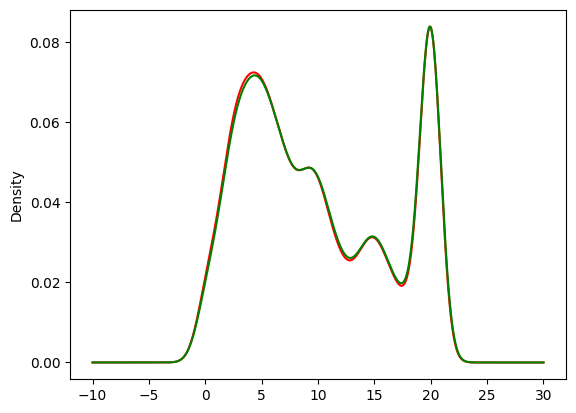

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['experience'].plot.density(color='red')
new_df['experience'].plot.density(color='green')


In [29]:
# Categories
# ratio of all the categories must maintain after CCA

In [30]:
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    df['enrolled_university'].value_counts() / len(new_df)
],
                 axis = 1)
temp.columns = ['original', 'cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.804156
Full time course,0.196106,0.218659
Part time course,0.062533,0.069724
